In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("blourdhuraju/intel-image-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 243M/243M [00:02<00:00, 118MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1):
['Intel-Image-Classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'test'))}")

Contents of the 'train' directory: ['street', 'sea', 'forest', 'glacier', 'mountain', 'buildings']
Contents of the 'test' directory: ['street', 'sea', 'forest', 'glacier', 'mountain', 'buildings']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/train) ---
Found 12632 images in /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/train. Displaying 6 samples:


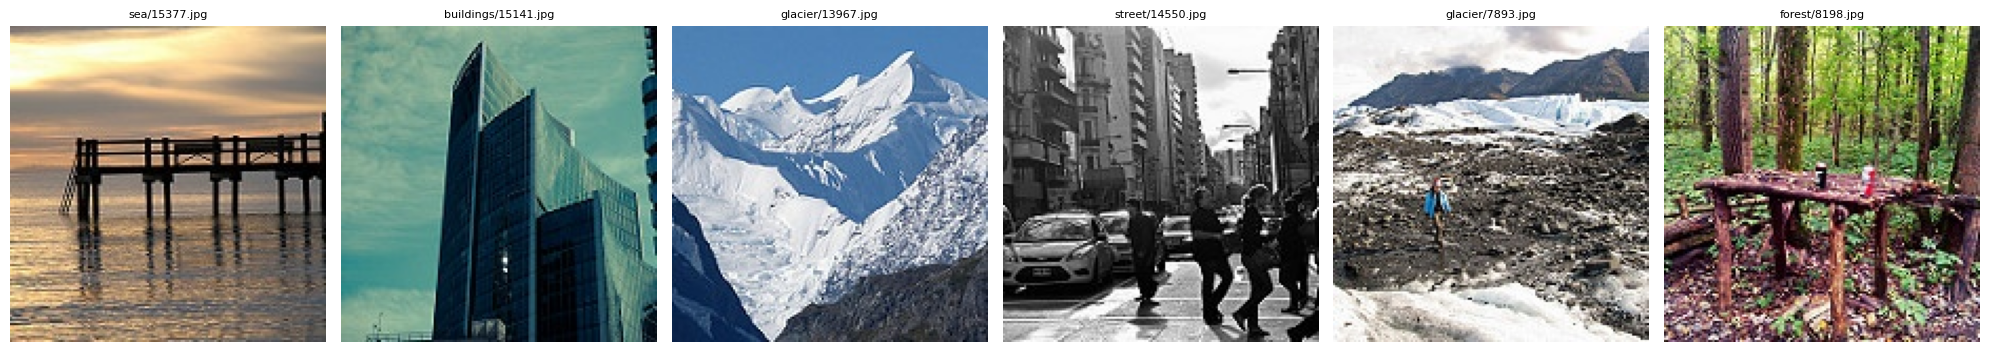


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/test) ---
Found 3000 images in /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/test. Displaying 6 samples:


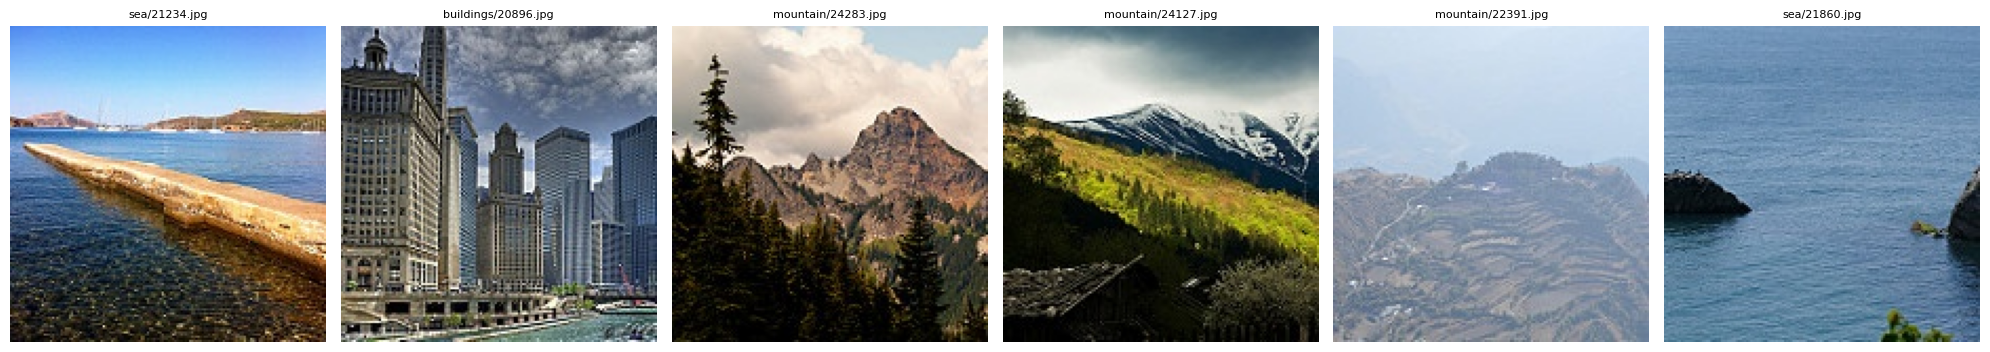

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Intel-Image-Classification' subdirectory
train_path = os.path.join(path, 'Intel-Image-Classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Intel-Image-Classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
# Data transformation and loading
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_path, transform=transform)
test_dataset = datasets.ImageFolder(test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define VGG model
model = models.vgg16(pretrained=True)
# Freeze features
for param in model.features.parameters():
    param.requires_grad = False

# Modify classifier
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, len(train_dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print(f'Model initialized with {len(train_dataset.classes)} output classes.')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 190MB/s]


Model initialized with 6 output classes.


In [ ]:
# Training loop
epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    history['val_loss'].append(val_loss / len(test_dataset))
    history['val_acc'].append(val_correct / val_total)

    print(f'Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, Val Loss: {history["val_loss"][-1]:.4f}, Val Acc: {history["val_acc"][-1]:.4f}')

Epoch 1/10 - Loss: 0.8098, Acc: 0.8436, Val Loss: 0.4334, Val Acc: 0.9000
Epoch 2/10 - Loss: 0.7168, Acc: 0.8693, Val Loss: 0.4325, Val Acc: 0.8963
Epoch 3/10 - Loss: 0.5902, Acc: 0.8852, Val Loss: 0.3318, Val Acc: 0.9067
Epoch 4/10 - Loss: 0.4534, Acc: 0.9010, Val Loss: 0.3997, Val Acc: 0.9147
Epoch 5/10 - Loss: 0.4966, Acc: 0.9034, Val Loss: 0.4820, Val Acc: 0.9117
Epoch 6/10 - Loss: 0.4972, Acc: 0.9029, Val Loss: 0.4867, Val Acc: 0.9080
Epoch 7/10 - Loss: 0.5573, Acc: 0.9112, Val Loss: 0.5056, Val Acc: 0.9063
Epoch 8/10 - Loss: 0.4343, Acc: 0.9204, Val Loss: 0.5709, Val Acc: 0.9137
Epoch 9/10 - Loss: 0.4036, Acc: 0.9261, Val Loss: 0.5515, Val Acc: 0.9120
Epoch 10/10 - Loss: 0.4109, Acc: 0.9273, Val Loss: 0.4273, Val Acc: 0.9103


In [ ]:
# Training Summary
print("--- Training Summary ---")
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
print(f"Final Training Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")

--- Training Summary ---
Final Training Accuracy: 92.73%
Final Validation Accuracy: 91.03%
Best Validation Accuracy: 91.47%


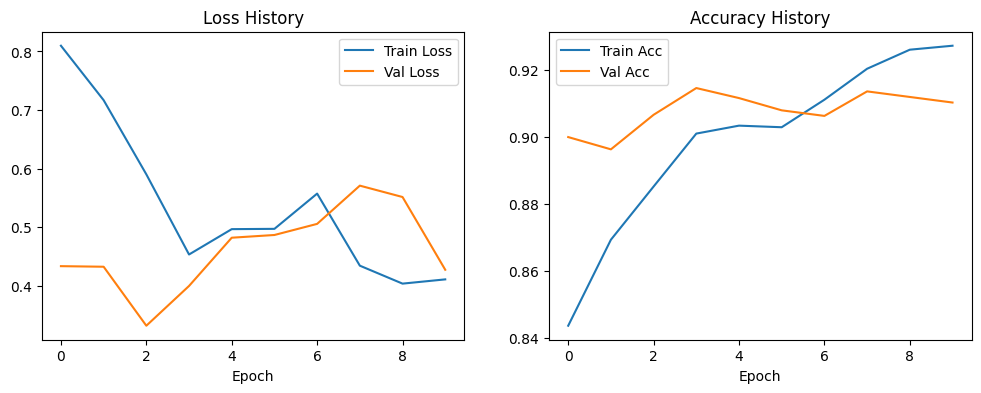

In [ ]:
# Plot Training History
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.legend()

plt.show()